In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:


df = pd.read_csv(r"C:\Users\Asus\Downloads\customer_value_regression.csv")
df.head()

,age,income,tenure_months,monthly_spend,transactions,website_visits,app_usage_hours,support_tickets,discount_usage,satisfaction_score,marketing_clicks,previous_purchases,days_since_last_purchase,products_owned,referrals,customer_value
0,56,39657.038,105,29.088,15,12,8.432,1,0.678,7.741,4,10,104,1,1,4212.895
1,69,63556.581,81,198.633,24,13,13.062,2,0.355,4.116,8,4,145,12,2,4224.153
2,46,66384.176,50,124.415,18,6,5.986,3,0.975,7.377,4,12,168,7,3,4096.836
3,32,46464.793,61,323.344,6,15,4.621,1,0.906,7.825,2,7,12,9,2,4230.788
4,60,41108.105,115,165.484,21,14,4.574,2,0.045,5.935,1,5,42,3,0,4208.395


In [4]:
df.shape

(10000, 16)

In [12]:
X = df.drop("customer_value", axis=1)

y = df["customer_value"]

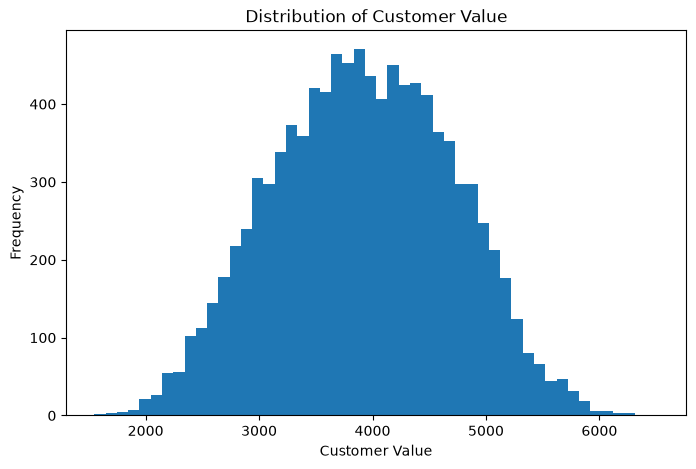

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=50)

plt.xlabel("Customer Value")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Value")

plt.show()

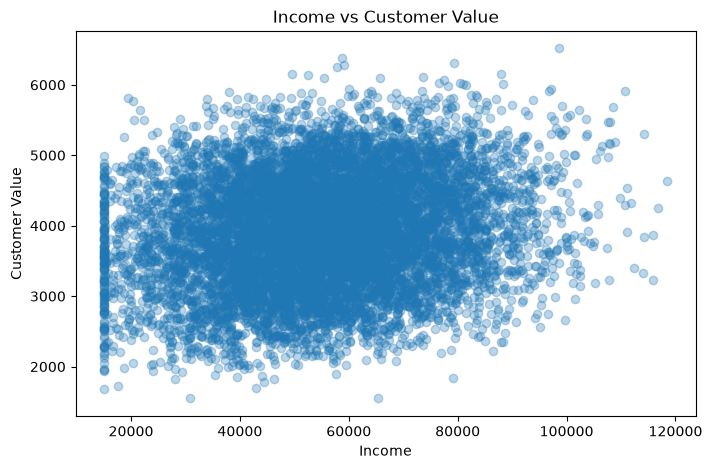

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(df["income"], df["customer_value"], alpha=0.3)

plt.xlabel("Income")
plt.ylabel("Customer Value")
plt.title("Income vs Customer Value")

plt.show()

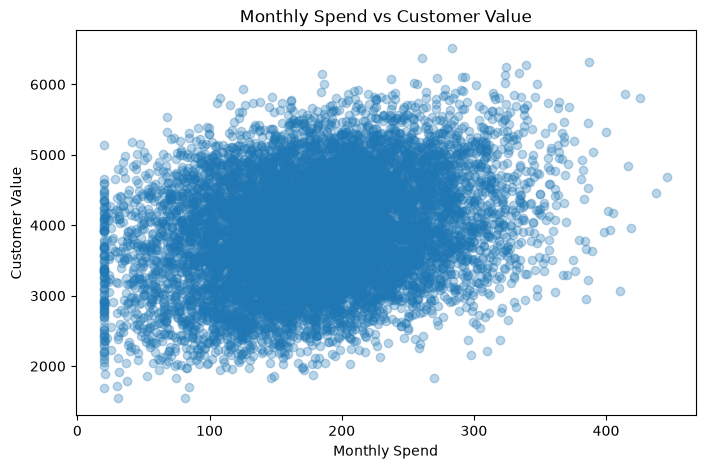

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(df["monthly_spend"], df["customer_value"], alpha=0.3)

plt.xlabel("Monthly Spend")
plt.ylabel("Customer Value")
plt.title("Monthly Spend vs Customer Value")

plt.show()

In [14]:
correlation = df.corr(numeric_only=True)

correlation["customer_value"].sort_values(ascending=False)

customer_value              1.000000
tenure_months               0.800026
satisfaction_score          0.299242
monthly_spend               0.282580
products_owned              0.187941
income                      0.179490
previous_purchases          0.133125
transactions                0.123522
discount_usage              0.069504
referrals                   0.067571
age                         0.055564
app_usage_hours             0.050032
website_visits              0.019029
marketing_clicks            0.015699
support_tickets            -0.013650
days_since_last_purchase   -0.153638
Name: customer_value, dtype: float64

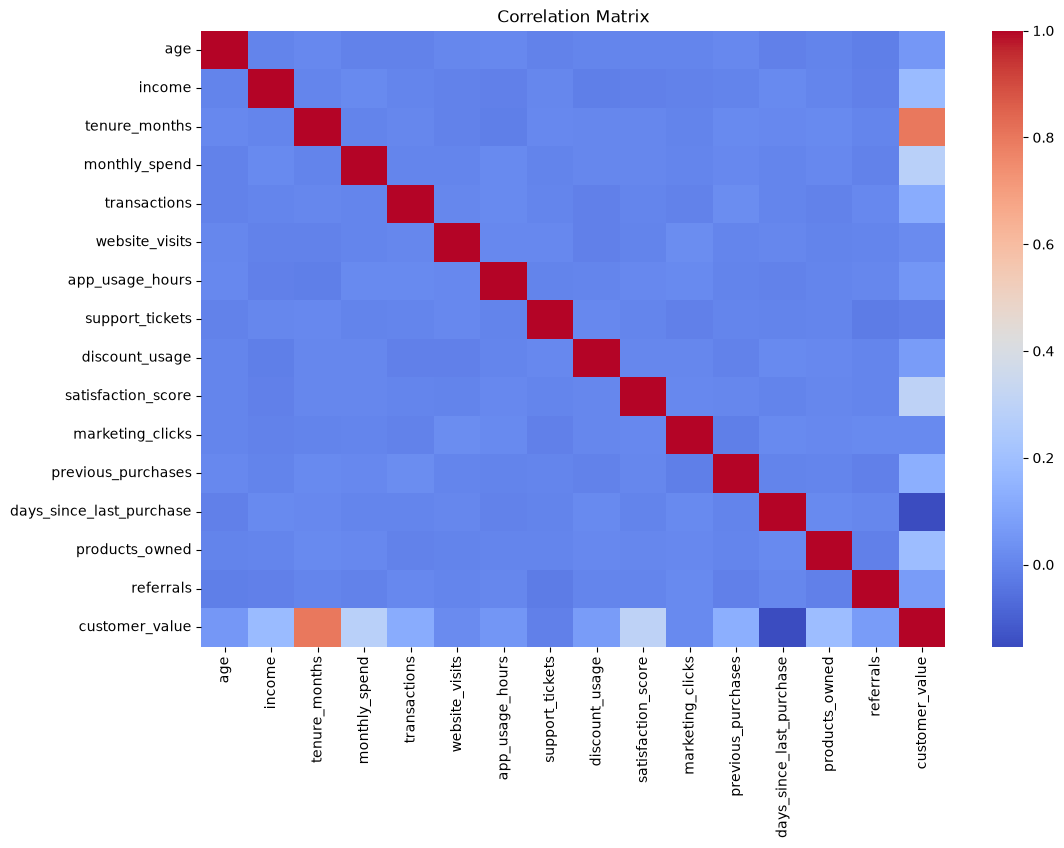

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:


X = df.drop("customer_value", axis=1)
y = df["customer_value"]

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [19]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1))

y_val_scaled = y_scaler.transform(y_val.to_numpy().reshape(-1, 1))

y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1, 1))

In [20]:
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

y_train_scaled = y_train_scaled.astype("float32")
y_val_scaled = y_val_scaled.astype("float32")
y_test_scaled = y_test_scaled.astype("float32")

In [21]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[ 1.4305115e-09 -1.4305115e-09 -4.7683718e-10 -1.9073487e-09
  3.5762786e-09 -5.7220459e-09  9.5367436e-10 -1.0490417e-08
  0.0000000e+00  0.0000000e+00 -7.1525574e-10  5.6028364e-09
 -4.7683718e-10  9.5367430e-09  3.8146974e-09]
[1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999994 0.99999994]


In [22]:
import joblib

joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(y_scaler, "target_scaler.pkl")

['target_scaler.pkl']

In [23]:
!pip install -q keras-tuner

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

In [25]:
def build_model(hp):

    model = keras.Sequential()

    model.add(layers.Input(shape=(15,)))

    model.add(
        layers.Dense(
            units=hp.Int(
                "units_1",
                min_value=64,
                max_value=128,
                step=16
            ),
            activation="relu"
        )
    )

    model.add(
        layers.Dense(
            units=hp.Int(
                "units_2",
                min_value=128,
                max_value=192,
                step=16
            ),
            activation="relu"
        )
    )

    model.add(
        layers.Dense(
            units=hp.Int(
                "units_3",
                min_value=32,
                max_value=96,
                step=16
            ),
            activation="relu"
        )
    )

    model.add(
        layers.Dense(1)
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            0.0001,
            0.0005,
            0.001,
            0.005
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [26]:
model = build_model(
    kt.HyperParameters()
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    executions_per_trial=1,
    directory="keras_tuner",
    project_name="customer_value_regression",
    overwrite=False
)

Reloading Tuner from keras_tuner\customer_value_regression\tuner0.json


In [28]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 192, 'step': 16, 'sampling': 'linear'}
units_3 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 96, 'step': 16, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.0005, 0.001, 0.005], 'ordered': True}


In [29]:
tuner.search(
    X_train_scaled,
    y_train_scaled,
    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),
    epochs=50,
    batch_size=32,
    verbose=1
)

Trial 20 Complete [00h 00m 55s]
val_loss: 0.06223864108324051

Best val_loss So Far: 0.0593065582215786
Total elapsed time: 00h 19m 16s


In [32]:
tuner.results_summary()

Results summary
Results in keras_tuner\customer_value_regression
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 02 summary
Hyperparameters:
units_1: 64
units_2: 160
units_3: 96
learning_rate: 0.005
Score: 0.06041780114173889

Trial 03 summary
Hyperparameters:
units_1: 96
units_2: 128
units_3: 32
learning_rate: 0.005
Score: 0.06145182251930237

Trial 08 summary
Hyperparameters:
units_1: 112
units_2: 192
units_3: 48
learning_rate: 0.001
Score: 0.06196097284555435

Trial 09 summary
Hyperparameters:
units_1: 80
units_2: 128
units_3: 48
learning_rate: 0.001
Score: 0.062007732689380646

Trial 10 summary
Hyperparameters:
units_1: 96
units_2: 160
units_3: 80
learning_rate: 0.0005
Score: 0.06241007149219513

Trial 17 summary
Hyperparameters:
units_1: 128
units_2: 176
units_3: 80
learning_rate: 0.001
Score: 0.0625491514801979

Trial 01 summary
Hyperparameters:
units_1: 128
units_2: 160
units_3: 96
learning_rate: 0.005
Score: 0.06281644105911255

Trial 14 summary
Hyperp

In [33]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [34]:
print("units_1:", best_hp.get("units_1"))
print("units_2:", best_hp.get("units_2"))
print("units_3:", best_hp.get("units_3"))
print("learning_rate:", best_hp.get("learning_rate"))

units_1: 64
units_2: 160
units_3: 96
learning_rate: 0.005


In [38]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

In [36]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 160)                 │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 96)                  │          15,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,977 (105.38 KB)

 Trainable params: 26,977 (105.38 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
best_model.count_params()

26977

In [39]:
for layer in best_model.layers:

    if isinstance(layer, layers.Dense):

        print(layer.name)

        print(
            "Weights:",
            layer.weights[0].shape
        )

        print(
            "Bias:",
            layer.weights[1].shape
        )

        print()

dense
Weights: (15, 64)
Bias: (64,)

dense_1
Weights: (64, 160)
Bias: (160,)

dense_2
Weights: (160, 96)
Bias: (96,)

dense_3
Weights: (96, 1)
Bias: (1,)



In [2]:
best_model.evaluate(
    X_val_scaled,
    y_val_scaled,
    verbose=1 , 
    return_dict=True
    
)


NameError: name 'best_model' is not defined

In [41]:
best_params = {
    "units_1": best_hp.get("units_1"),
    "units_2": best_hp.get("units_2"),
    "units_3": best_hp.get("units_3"),
    "learning_rate": best_hp.get("learning_rate")
}

best_params

{'units_1': 64, 'units_2': 160, 'units_3': 96, 'learning_rate': 0.005}

In [42]:
best_model.save(
    "best_customer_value_model.keras"
)

In [43]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [44]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

In [45]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

In [46]:
history = best_model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0587 - mae: 0.1939 - val_loss: 0.0624 - val_mae: 0.1988 - learning_rate: 0.0050
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0559 - mae: 0.1887 - val_loss: 0.0637 - val_mae: 0.2018 - learning_rate: 0.0050
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0551 - mae: 0.1867 - val_loss: 0.0623 - val_mae: 0.1982 - learning_rate: 0.0050
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0537 - mae: 0.1852 - val_loss: 0.0764 - val_mae: 0.2199 - learning_rate: 0.0050
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0525 - mae: 0.1825 - val_loss: 0.0742 - val_mae: 0.2170 - learning_rate: 0.0050
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0524 - mae: 0.1825 - val_loss: 0.0699 - val_mae: 0.2106 - learning_rate: 0.0050
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0461 - mae: 0.1712 - val_loss: 0.0624 - val_mae: 0.2007 - learning_rate: 0.0025

In [47]:
len(history.history["loss"])

13

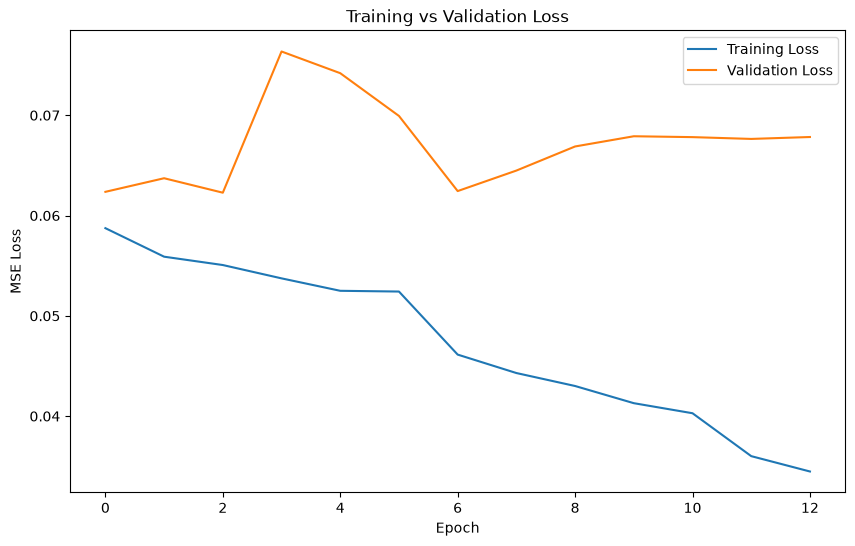

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

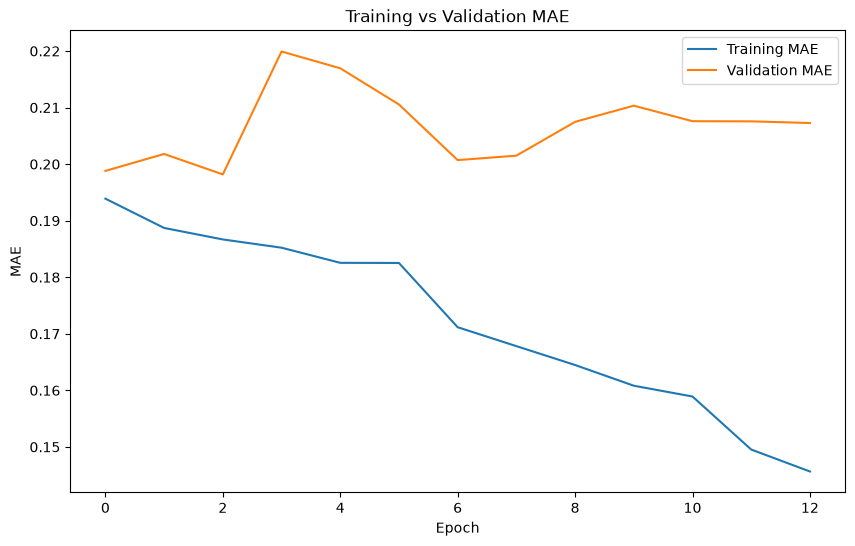

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.show()

In [50]:
best_val_loss = min(
    history.history["val_loss"]
)

print("Best Validation Loss:", best_val_loss)

Best Validation Loss: 0.062280260026454926


In [51]:
best_epoch = (
    history.history["val_loss"].index(
        min(history.history["val_loss"])
    ) + 1
)

print("Best Epoch:", best_epoch)

Best Epoch: 3


In [52]:
lr_callback = keras.callbacks.LearningRateScheduler(
    lambda epoch: 0.001
)

In [53]:
class LearningRateLogger(
    keras.callbacks.Callback
):

    def on_epoch_end(self, epoch, logs=None):

        lr = float(
            tf.keras.backend.get_value(
                self.model.optimizer.learning_rate
            )
        )

        print(
            f"Epoch {epoch + 1}: "
            f"Learning Rate = {lr:.7f}"
        )

In [54]:
history = best_model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint,
        LearningRateLogger()
    ]
)

Epoch 1/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0474 - mae: 0.1734Epoch 1: Learning Rate = 0.0012500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0473 - mae: 0.1733 - val_loss: 0.0604 - val_mae: 0.1965 - learning_rate: 0.0012
Epoch 2/100
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0448 - mae: 0.1686Epoch 2: Learning Rate = 0.0012500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0448 - mae: 0.1685 - val_loss: 0.0611 - val_mae: 0.1976 - learning_rate: 0.0012
Epoch 3/100
236/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0438 - mae: 0.1664Epoch 3: Learning Rate = 0.0012500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0437 - mae: 0.1664 - val_loss: 0.0616 - val_mae: 0.1974 - learning_rate: 0.0012
Epoch 4/100
242/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0422 - mae: 0.1635Epoch 4: Learning Rate = 0.0012500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0423 - mae: 0.1635 - val_loss: 0.0656 - val_mae: 0.2044 - learning_rate: 0.0012
Epoch 5/100


In [55]:
best_model = keras.models.load_model(
    "best_model.keras"
)

In [56]:
best_model.evaluate(
    X_val_scaled,
    y_val_scaled,
    verbose=1
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0604 - mae: 0.1965


[0.06040572375059128, 0.196534663438797]

In [57]:
import json

with open(
    "training_history.json",
    "w"
) as f:

    json.dump(
        history.history,
        f
    )

In [58]:

model = keras.models.load_model("best_model.keras")

In [59]:
y_pred_scaled = model.predict(X_test_scaled)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [60]:
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_scaled)

In [61]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 150.29750061035156
MSE : 35804.6328125
RMSE: 189.2211214756429
R²  : 0.9423956871032715


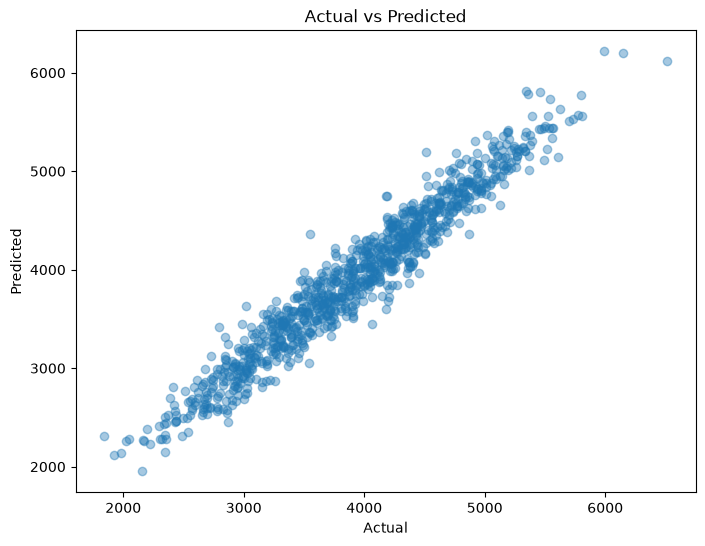

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [63]:
new_customer = np.array([[
    35,        # age
    60000,     # income
    48,        # tenure_months
    220,       # monthly_spend
    20,        # transactions
    15,        # website_visits
    8,         # app_usage_hours
    2,         # support_tickets
    0.3,       # discount_usage
    8.5,       # satisfaction_score
    6,         # marketing_clicks
    12,        # previous_purchases
    20,        # days_since_last_purchase
    6,         # products_owned
    2          # referrals
]])

In [70]:
new_customer_scaled = scaler.transform(
    new_customer
)

C:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [66]:
prediction_scaled = model.predict(
    new_customer_scaled
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [68]:
prediction = y_scaler.inverse_transform(
    prediction_scaled
)

print("Predicted Customer Value:", prediction[0][0])

Predicted Customer Value: 4326.4126


In [69]:
def predict_customer_value(data):

    data_scaled = scaler.transform(data)

    prediction_scaled = model.predict(
        data_scaled,
        verbose=0
    )

    prediction = y_scaler.inverse_transform(
        prediction_scaled
    )

    return prediction.flatten()

In [71]:
result = predict_customer_value(
    new_customer
)

print(result)

[4326.4126]


C:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [73]:
model.save("customer_value_model.keras")

In [74]:
import joblib

joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(y_scaler, "target_scaler.pkl")

['target_scaler.pkl']

In [75]:
from tensorflow import keras

loaded_model = keras.models.load_model(
    "customer_value_model.keras"
)

In [76]:
loaded_scaler = joblib.load(
    "feature_scaler.pkl"
)

loaded_y_scaler = joblib.load(
    "target_scaler.pkl"
)

In [77]:
import numpy as np

def predict_customer_value(data):

    data = np.array(data).reshape(1, -1)

    data_scaled = loaded_scaler.transform(data)

    prediction_scaled = loaded_model.predict(
        data_scaled,
        verbose=0
    )

    prediction = loaded_y_scaler.inverse_transform(
        prediction_scaled
    )

    return float(prediction[0][0])

In [78]:
customer = [[
    35,
    60000,
    48,
    220,
    20,
    15,
    8,
    2,
    0.3,
    8.5,
    6,
    12,
    20,
    6,
    2
]]

In [79]:
result = predict_customer_value(customer)

print(f"Predicted Customer Value: {result:.2f}")

C:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Customer Value: 4326.41


In [80]:
results = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

results

{'MAE': 150.29750061035156,
 'MSE': 35804.6328125,
 'RMSE': np.float64(189.2211214756429),
 'R2': 0.9423956871032715}

In [81]:
best_params

{'units_1': 64, 'units_2': 160, 'units_3': 96, 'learning_rate': 0.005}